In [ ]:
import chess_utils
import RL_utils
from chess import Board
import torch

In [ ]:
from dataclasses import dataclass, field
from typing import List

@dataclass
class IterationMetrics:
      iteration: int
      # Self-play
      game_lengths: List[int] = field(default_factory=list)
      results: List[float] = field(default_factory=list) # WHITE's POV
      policy_entropies: List[float] = field(default_factory=list)
      terminations: dict = field(default_factory=lambda: {'checkmate': 0, 'draw': 0, 'truncated': 0})
      # Training
      total_losses: List[float] = field(default_factory=list)
      policy_losses: List[float] = field(default_factory=list)
      value_losses: List[float] = field(default_factory=list)
      kl_divs: List[float] = field(default_factory=list)
      grad_norms: List[float] = field(default_factory=list)
      value_sign_accuracy: List[float] = field(default_factory=list)
      value_weighted: List[float] = field(default_factory=list)

all_metrics: List[IterationMetrics] = []

In [ ]:
model, device = RL_utils.load_resnet_model('models/value_calibrated_checkpoint.pth')
checkpoint = torch.load('models/rlmodel_buffer_iter18.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# cnn_model, device = RL_utils.load_resnet_model('models/CNN_ResNet.pth', input_channels=19)
# cnn_model.eval()

In [ ]:
checkpoint = torch.load("models/best_checkpoint.pth", map_location='cpu')
print(f"Saved epoch : {checkpoint['epoch']}")
print(f"Val loss    : {checkpoint['val_loss']:.4f}")

## Play out Main Line

In [ ]:
board = Board()
cnn_board = Board()
mcts_board = Board()

In [ ]:
best_move = chess_utils.test_single_position(model, board, device)
board.push_uci(str(best_move))
board

In [ ]:
# CNN model prediction
cnn_best_move = chess_utils.test_single_position(cnn_model, cnn_board, device)
cnn_board.push_uci(str(cnn_best_move))
cnn_board

In [ ]:
from chess_utils import board_to_tensor

tensor = torch.tensor(board_to_tensor(board), dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad():
    _, value = model(tensor)
print(f"Value estimate (White's POV): {value.item():.3f}")

In [ ]:
from mcts import SimpleMCTS

def get_mcts_move(model, board, device, num_simulations=100):
    mcts = SimpleMCTS(model, device, num_simulations=num_simulations)
    action_probs, root = mcts.get_action_probs(board, temperature=0)
    if not action_probs:
        return None
    best_move = max(action_probs, key=action_probs.get)
    sorted_moves = sorted(root.children.items(),
                         key=lambda x: x[1].visits, reverse=True)[:5]
    print("Top 5 MCTS moves:")
    for move, node in sorted_moves:
        print(f"  {move}: visits={node.visits}, value={node.value():.3f}")
    return best_move

In [ ]:
best = get_mcts_move(model, mcts_board, device)
mcts_board.push(best)
mcts_board

## Compare moves between models

In [ ]:
import chess
test_board = chess.Board()  # fresh starting position

print("=== CNN raw policy ===")
chess_utils.test_single_position(cnn_model, test_board, device)

print("\n=== RL raw policy ===")
chess_utils.test_single_position(model, test_board, device)

print("\n=== MCTS search ===")
get_mcts_move(model, test_board, device)

In [ ]:
# After 1.e4 e5
test_board = chess.Board()
test_board.push_uci("e2e4")
test_board.push_uci("e7e5")

print("=== CNN after 1.e4 e5 ===")
chess_utils.test_single_position(cnn_model, test_board, device)
print("\n=== RL after 1.e4 e5 ===")
chess_utils.test_single_position(model, test_board, device)

In [ ]:
# After 1.e4 e5
test_board = chess.Board()
test_board.push_uci("e2e4")
test_board.push_uci("e7e5")

print("=== CNN after 1.e4 e5 ===")
chess_utils.test_single_position(cnn_model, test_board, device)
print("\n=== RL after 1.e4 e5 ===")
chess_utils.test_single_position(model, test_board, device)

## Tactical check

In [ ]:
from chess_utils import board_to_tensor

board = Board("6k1/5ppp/8/8/8/8/7K/3qR3 w - - 0 1")  # Re8#

tensor = torch.tensor(board_to_tensor(board), dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad():
    _, value = model(tensor)
print(f"Value estimate (White's POV): {value.item():.3f}")

top_move = chess_utils.test_single_position(model, board, device, debug=True)
board.push_uci(str(top_move))
board

# Play out benchmarking games

### Vs Stockfish

In [ ]:
import chess

def play_vs_stockfish(model, device, stockfish_path, num_games=40, stockfish_elo=1320):
    engine = chess.engine.SimpleEngine.popen_uci(stockfish_path)
    engine.configure({"UCI_LimitStrength": True, "UCI_Elo": stockfish_elo})

    results = {"model_win": 0, "draw": 0, "stockfish_win": 0}

    for game_num in range(num_games):
        board = chess.Board()
        model_is_white = (game_num % 2 == 0)

        while not board.is_game_over():
            if board.turn == chess.WHITE and model_is_white or \
               board.turn == chess.BLACK and not model_is_white:
                move = chess_utils.test_single_position(model, board, device, debug=False)
                if move not in board.legal_moves:
                    move = list(board.legal_moves)[0]  # fallback
            else:
                result = engine.play(board, chess.engine.Limit(time=0.1))
                move = result.move
            board.push(move)

        outcome = board.outcome()
        if outcome.winner is None:
            results["draw"] += 1
        elif (outcome.winner == chess.WHITE) == model_is_white:
            results["model_win"] += 1
        else:
            results["stockfish_win"] += 1

        print(f"Game {game_num+1}: {board.result()}")

    engine.quit()
    print(f"\nResults: {results}")
    return results

In [ ]:
# model, device = RL_utils.load_resnet_model('models/value_calibrated_checkpoint.pth')
# model.eval()
results = play_vs_stockfish(model, device, stockfish_path='models/stockfish/stockfish-ubuntu-x86-64-avx2', num_games=50, stockfish_elo=1320)

In [ ]:
import stockfish_utils

positions = [Board() for _ in range(100)]

model, device = RL_utils.load_resnet_model('models/value_calibrated_checkpoint.pth')
model.eval()
sf_data, sf_stats = stockfish_utils.generate_stockfish_games(
    model, device, 'models/stockfish/stockfish-ubuntu-x86-64-avx2', positions,
    num_games=50, stockfish_elo=1320,
    num_simulations=500
)
print(sf_stats['win_rate'])

### Vs Original CNN

In [ ]:
import chess

def evaluate_vs_cnn(rl_model, cnn_model, device, num_games=50, num_simulations=100):
    from mcts import SimpleMCTS
    results = {'rl_win': 0, 'cnn_win': 0, 'draw': 0}

    for game_idx in range(num_games):
        board = chess.Board()
        rl_is_white = (game_idx % 2 == 0)

        # Each side gets its own MCTS instance — tree reuse is per-side
        rl_mcts = SimpleMCTS(rl_model, device, num_simulations)
        cnn_mcts = SimpleMCTS(cnn_model, device, num_simulations)
        move_count = 0

        while not board.is_game_over(claim_draw=True) and move_count < 150:
            is_rl_turn = (board.turn == chess.WHITE) == rl_is_white
            active_mcts = rl_mcts if is_rl_turn else cnn_mcts
            inactive_mcts = cnn_mcts if is_rl_turn else rl_mcts

            action_probs, _ = active_mcts.get_action_probs(board, temperature=0)
            move = max(action_probs, key=action_probs.get)
            board.push(move)

            # Advance the active side's tree to the played subtree
            active_mcts.advance_root(move)
            # The inactive side tries to advance too; falls back to fresh if not explored
            inactive_mcts.advance_root(move)

            move_count += 1

        result = RL_utils.get_game_result(board)
        if result == 0:
            results['draw'] += 1
        elif (result > 0) == rl_is_white:
            results['rl_win'] += 1
        else:
            results['cnn_win'] += 1

        print(f"Game {game_idx+1}: {'RL' if rl_is_white else 'CNN'} as White | "
              f"Result: {result:+.0f} | Moves: {move_count}")

    print(f"\nRL wins: {results['rl_win']}, CNN wins: {results['cnn_win']}, "
          f"Draws: {results['draw']}")
    return results

In [ ]:
evaluate_vs_cnn(model, cnn_model, device, num_games=50, num_simulations=100)

In [ ]:
import random

def evaluate_vs_cnn_varied(rl_model, cnn_model, device, 
                            start_positions, num_games=60, 
                            num_simulations=100):
    """
    Evaluates across opening, middlegame, and endgame positions.
    start_positions should be your full mixed position set.
    """
    from mcts import SimpleMCTS
    results = {'rl_win': 0, 'cnn_win': 0, 'draw': 0}
    phase_results = {'opening': [], 'middlegame': [], 'endgame': []}

    for game_idx in range(num_games):
        start_board = random.choice(start_positions).copy()
        
        # Classify starting position phase for tracking
        piece_count = len(start_board.piece_map())
        move_num = start_board.fullmove_number
        if piece_count <= 10:
            phase = 'endgame'
        elif move_num <= 5:
            phase = 'opening'
        else:
            phase = 'middlegame'

        board = start_board.copy()
        rl_is_white = (game_idx % 2 == 0)
        rl_mcts = SimpleMCTS(rl_model, device, num_simulations)
        cnn_mcts = SimpleMCTS(cnn_model, device, num_simulations)
        move_count = 0

        while not board.is_game_over(claim_draw=True) and move_count < 150:
            is_rl_turn = (board.turn == chess.WHITE) == rl_is_white
            active_mcts  = rl_mcts  if is_rl_turn else cnn_mcts
            inactive_mcts = cnn_mcts if is_rl_turn else rl_mcts
            action_probs, _ = active_mcts.get_action_probs(board, temperature=0)
            if not action_probs:
                break
            move = max(action_probs, key=action_probs.get)
            board.push(move)
            active_mcts.advance_root(move)
            inactive_mcts.advance_root(move)
            move_count += 1

        result = RL_utils.get_game_result(board)
        
        if result == 0:
            results['draw'] += 1
            phase_results[phase].append(0)
        elif (result > 0) == rl_is_white:
            results['rl_win'] += 1
            phase_results[phase].append(1)
        else:
            results['cnn_win'] += 1
            phase_results[phase].append(-1)

        print(f"Game {game_idx+1} [{phase}]: "
              f"{'RL' if rl_is_white else 'CNN'} as White | "
              f"Result: {result:+.0f} | Moves: {move_count}")

    print(f"\nOverall — RL wins: {results['rl_win']}, "
          f"CNN wins: {results['cnn_win']}, Draws: {results['draw']}")
    print("\nBy phase:")
    for phase, res in phase_results.items():
        if res:
            rl_score = (sum(r == 1 for r in res) + 
                       0.5 * sum(r == 0 for r in res)) / len(res)
            print(f"  {phase}: {len(res)} games, "
                  f"RL score={rl_score:.1%}")
    return results, phase_results

In [ ]:
PGN_FILE = "games/lichess_db_2016-04.pgn"
positions = []
# Opening positions
opening_positions = [Board() for _ in range(500)]  # starting position
positions += opening_positions
# Middlegame positions
positions += RL_utils.extract_varied_positions(PGN_FILE, num_positions=350)
#Endgame positions
positions += RL_utils.extract_checkmate_positions(num_positions=150)
# Mate in one positions
positions += RL_utils.load_mate_in_one_positions()
print(f"Total positions loaded: {len(positions)}")
evaluate_vs_cnn_varied(model, cnn_model, device, positions, num_games=50, num_simulations=100)

### Recorded gamethat can be played back in analysis board

In [ ]:
import chess
import chess.pgn
import torch
from mcts import SimpleMCTS
from chess_utils import board_to_tensor
from RL_utils import get_game_result

def play_annotated_game(rl_model, cnn_model, device, rl_is_white=True,
                        num_simulations=100, save_pgn_path=None):
    """
    Play a game between RL and CNN with full move-by-move analysis.
    Both models are queried at every position to highlight disagreements.
    Exports as PGN — paste into lichess.org/analysis to replay.
    """
    board = chess.Board()
    rl_mcts  = SimpleMCTS(rl_model,  device, num_simulations)
    cnn_mcts = SimpleMCTS(cnn_model, device, num_simulations)

    game_pgn = chess.pgn.Game()
    game_pgn.headers["White"] = "RL"  if rl_is_white else "CNN"
    game_pgn.headers["Black"] = "CNN" if rl_is_white else "RL"
    node = game_pgn

    records = []
    move_count = 0

    print(f"{'RL' if rl_is_white else 'CNN'} plays White | {num_simulations} simulations each")
    print("=" * 70)
    print(f"{'Move':<8} {'Player':<6} {'Played':<8} {'RL wants':<10} "
          f"{'CNN wants':<10} {'RL val':>8} {'CNN val':>8}")
    print("-" * 70)

    while not board.is_game_over(claim_draw=True) and move_count < 250:
        is_rl_turn = (board.turn == chess.WHITE) == rl_is_white

        # Both models search the position
        rl_probs,  _ = rl_mcts.get_action_probs(board, temperature=0)
        cnn_probs, _ = cnn_mcts.get_action_probs(board, temperature=0)

        rl_best  = max(rl_probs,  key=rl_probs.get)  if rl_probs  else None
        cnn_best = max(cnn_probs, key=cnn_probs.get) if cnn_probs else None
        chosen   = rl_best if is_rl_turn else cnn_best

        # Value estimates from raw model (no MCTS)
        with torch.no_grad():
            t = torch.tensor(board_to_tensor(board),
                             dtype=torch.float32).unsqueeze(0).to(device)
            _, rl_v  = rl_model(t)
            _, cnn_v = cnn_model(t)
        rl_val  = float(rl_v.item())
        cnn_val = float(cnn_v.item())

        # Formatted move string
        full_move  = board.fullmove_number
        side_dot   = "." if board.turn == chess.WHITE else "..."
        move_label = f"{full_move}{side_dot}"
        player     = "RL" if is_rl_turn else "CNN"

        rl_san  = board.san(rl_best)  if rl_best  else "—"
        cnn_san = board.san(cnn_best) if cnn_best else "—"
        play_san = board.san(chosen)
        flag    = " ◄" if rl_best != cnn_best else ""

        print(f"{move_label:<8} {player:<6} {play_san:<8} {rl_san:<10} "
              f"{cnn_san:<10} {rl_val:>+8.3f} {cnn_val:>+8.3f}{flag}")

        records.append({
            'fen': board.fen(), 'move_label': move_label, 'player': player,
            'played': chosen, 'rl_best': rl_best, 'cnn_best': cnn_best,
            'rl_val': rl_val, 'cnn_val': cnn_val,
            'disagrees': rl_best != cnn_best
        })

        node = node.add_variation(chosen)
        board.push(chosen)
        move_count += 1

    # Result
    result = get_game_result(board)
    result_str = "1-0" if result > 0 else ("0-1" if result < 0 else "1/2-1/2")
    game_pgn.headers["Result"] = result_str

    rl_won = (result > 0 and rl_is_white) or (result < 0 and not rl_is_white)
    winner = "RL wins" if (result != 0 and rl_won) else ("CNN wins" if result != 0 else "Draw")

    print("=" * 70)
    print(f"Result: {result_str}  →  {winner}")

    # Disagreement summary
    disagrees = [r for r in records if r['disagrees']]
    print(f"Disagreements: {len(disagrees)}/{move_count} moves ({len(disagrees)/max(move_count,1):.0%})")

    # Where values diverged most — often where the game was decided
    records_sorted = sorted(records, key=lambda r: abs(r['rl_val'] - r['cnn_val']), reverse=True)
    print(f"\nTop 5 positions where RL and CNN value estimates diverged:")
    for r in records_sorted[:5]:
        b = chess.Board(r['fen'])
        diff = r['rl_val'] - r['cnn_val']
        rl_san  = b.san(r['rl_best'])  if r['rl_best']  else "—"
        cnn_san = b.san(r['cnn_best']) if r['cnn_best'] else "—"
        print(f"  {r['move_label']:8} RL={r['rl_val']:+.3f} CNN={r['cnn_val']:+.3f} "
              f"(Δ={diff:+.3f})  RL→{rl_san}  CNN→{cnn_san}")

    # Export PGN
    pgn_text = str(game_pgn)
    if save_pgn_path:
        with open(save_pgn_path, 'w') as f:
            f.write(pgn_text)
        print(f"\nPGN saved to: {save_pgn_path}")
    
    print(f"\nPGN (paste into lichess.org/analysis or chess.com/analysis):")
    print("-" * 70)
    print(pgn_text)

    return result, records, pgn_text


# --- Usage ---
# Single game, RL as White
result, records, pgn = play_annotated_game(
    model, cnn_model, device,
    rl_is_white=True,
    num_simulations=100,
    save_pgn_path="diagnostics/game_analysis.pgn"
)

# Run a few games alternating sides
# for game_num in range(4):
#     print(f"\n\n{'#'*70}")
#     print(f"# GAME {game_num + 1}")
#     print(f"{'#'*70}")
#     play_annotated_game(model, cnn_model, device,
#                         rl_is_white=(game_num % 2 == 0),
#                         num_simulations=100)

## Test Value Head - how well does the model estimate current eval

Model loaded from models/value_calibrated_checkpoint.pth
[opening] n=80  MSE=0.0247  sign_agreement=77.5%  correlation=0.675
[middlegame] n=80  MSE=0.1309  sign_agreement=67.5%  correlation=0.664
[endgame] n=79  MSE=0.1804  sign_agreement=82.3%  correlation=0.838


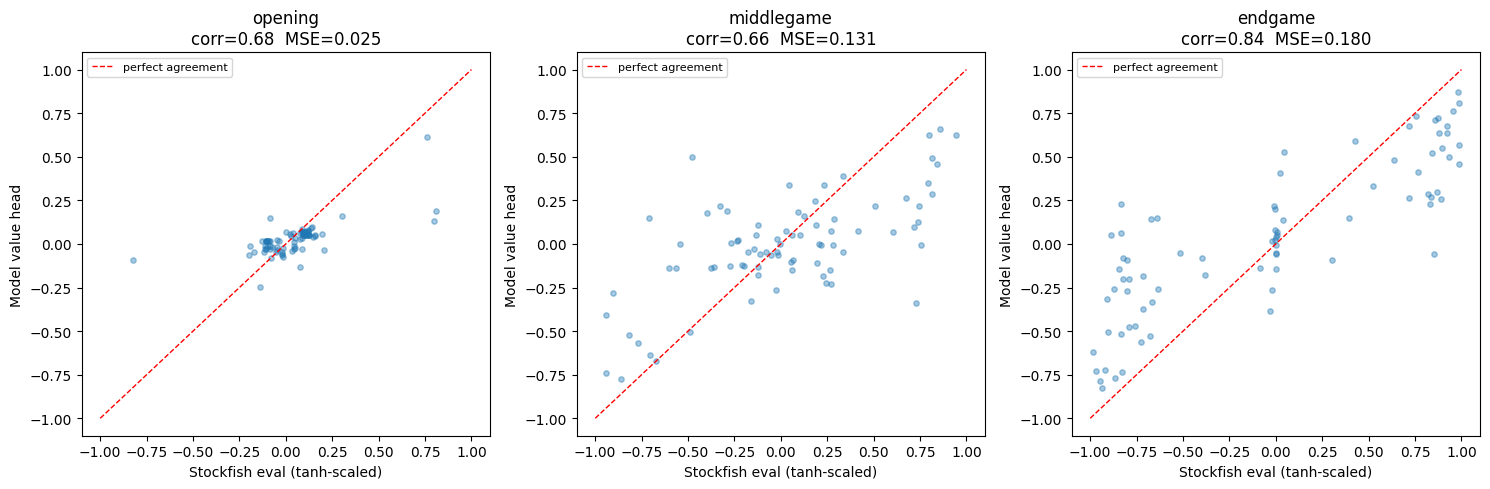

In [ ]:
import value_calibration as vc
import RL_utils

model, device = RL_utils.load_resnet_model('models/value_calibrated_checkpoint.pth')
phases = vc.sample_positions_by_phase("games/lichess_db_standard_rated_2026-04.pgn", n_per_phase=80)
results = vc.compare_value_head_to_stockfish(model, device, phases,
    'models/stockfish/stockfish-ubuntu-x86-64-avx2', depth=12)
vc.plot_value_comparison(results)

# Test MCTS Speed

In [ ]:
import time
import random
import numpy as np
 
def benchmark_self_play(model, device, start_positions, num_games=5, num_simulations=200):
    times = []
    game_lengths = []
    for _ in range(num_games):
        board = random.choice(start_positions).copy()
        mcts = SimpleMCTS(model, device, num_simulations)
        start = time.time()
        move_count = 0
        while not board.is_game_over(claim_draw=True) and move_count < 100:
            action_probs, _ = mcts.get_action_probs(board, temperature=1.0)
            move = random.choice(list(action_probs.keys()))
            board.push(move)
            mcts.advance_root(move)
            move_count += 1
        times.append(time.time() - start)
        game_lengths.append(move_count)
        print(f"Game finished in {move_count} moves, took {times[-1]:.1f}s")
    print(f"Mean game time: {np.mean(times):.1f}s over {num_games} games")
    print(f"Mean game length: {np.mean(game_lengths):.1f} moves")
    return times

In [ ]:
positions = [Board() for _ in range(10)]
benchmark_self_play(model, device, positions, num_games=5, num_simulations=200)